# Score Aptitude Quiz

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [138]:
# Temporary Workaround to read Google Sheets from MacOs
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

## Download Data

In [139]:
RESPONSES = 'https://docs.google.com/spreadsheets/d/1jVQUR-HyVFfgZl8tk7Px-W6KQFvZZCNWAWXDJACHzJg/export?format=csv'

In [140]:
df = pd.read_csv(RESPONSES, dtype=str)
df.head()

,Timestamp,Email Address,Score,"Q1. An IT company recruits 40% of its total employees for the development team, 35% for the testing team, and the remaining 150 employees for infrastructure support. What is the total number of employees in the company?","Q2. The ratio of the salaries of a junior developer and a senior developer is 3 : 5. If the senior developer earns ₹40,000 more than the junior developer, what is the salary of the junior developer?","Q3. Arjun can write a basic automation script in 6 hours, while Vikram can write the same script in 12 hours. How long will it take them to write the script if they work together?","Q4. The average marks scored by a computer science batch of 5 students in a coding test is 85. If a 6th student joins the batch and scores 97 marks, what is the new average score of the batch?","Q5. A college graduate takes an education laptop loan of ₹50,000 at a 10% per annum Simple Interest rate. How much total interest will they pay at the end of 3 years?","Q6. A store sells a mechanical keyboard for ₹4,600, making a profit of 15%. What was the original cost price of the keyboard?",Q7. A data packet takes 4 milliseconds to travel from a local server to a device located 1200 meters away. What is the speed of transmission in meters per second (m/s)? (Note: 1 millisecond = 0.001 seconds),...,"Q16. Find the next letter in the sequence: Z, W, S, N, ?","Q17. In a batch of 50 engineering students, 35 know Python, 25 know Java, and 20 know both languages. How many students in the batch do not know either Python or Java?","Q18. Four programmers (W, X, Y, Z) are sitting in a row facing a projection screen. X is sitting to the immediate right of Y. W is sitting between Z and Y. Who is sitting at the extreme left end?","Q19. Identify the word that does not belong with the others: Python, Java, C++, Linux, Ruby","Q20. If today is Friday, what day of the week will it be exactly 22 days from now?","Q21. The closing price of an IT stock over five consecutive trading days is tracked as follows: Mon: ₹100, Tue: ₹150, Wed: ₹200, Thu: ₹120, Fri: ₹180. What is the percentage change in the stock price from Tuesday to Thursday?",Q22. What value will be printed at the end of this logic block?\nSet X = 15\nSet Y = 25\nIf X > 10 Then\n X = X + 5\nEnd If\nIf Y > X Then\n Print Y - X\nElse\n Print X - Y\nEnd If,Q23. What is the decimal equivalent of the binary number 1011?,"Q24. Which data structure operates strictly on a First-In, First-Out (FIFO) structural approach?","Q25. In a standard systems development flowchart symbol set, what structural step does a Diamond-shaped box represent?"
0,9/7/2026 13:29:47,23aids032@act.edu.in,10 / 25,500,"₹60,000",4 hours,88,"₹10,000","₹4,000","450,000 m/s",...,H,0,Y,Linux,Monday,20% decrease,5,11,Stack,Input / Output
1,9/7/2026 13:29:54,23aids041@act.edu.in,12 / 25,600,"₹60,000",4 hours,86,"₹15,000","₹4,000","450,000 m/s",...,H,0,Y,Linux,Monday,20% decrease,5,11,Stack,Input / Output
2,9/7/2026 13:34:07,nitaraboopathi28@gmail.com,22 / 25,750,"₹60,000",4 hours,87,"₹15,000","₹4,100","300,000 m/s",...,H,10,Z,Linux,Saturday,20% decrease,5,11,Queue,Decision
3,9/7/2026 13:35:56,tejasrik2006@gmail.com,18 / 25,500,"₹60,000",4 hours,87,"₹15,000","₹3,800","300,000 m/s",...,H,10,Z,Linux,Sunday,25% decrease,5,11,Queue,Decision
4,9/7/2026 13:36:45,23aids013@act.edu.in,22 / 25,600,"₹60,000",4 hours,87,"₹15,000","₹4,000","300,000 m/s",...,I,20,Z,Linux,Saturday,20% decrease,0,11,Queue,Decision


### Answer Keys

In [141]:
# questions = list(df.columns[3:])
questions = [f'Q{i+1}' for i in range(25)]
correct_answers = [           
    '600',           '₹60,000',    '4 hours',         '87',
    '₹15,000',       '₹4,000',     '300,000 m/s',     '45612',
    '24 ways',       '36 seconds', '57',              'D',
    '10 meters',     'Mother',     '3-12-9-5-14-20',  'H',
    '10',            'Z',          'Linux',           'Saturday',
    '20% decrease',  '5',          '11',              'Queue',
    'Decision'
]
CORRECT_ANSWERS = pd.Series(data=correct_answers, index=questions)

## Review Data

### How many respondents ?

In [142]:
df.index.size

40

In [143]:
df['Email Address'].nunique()

40

### Score Responses

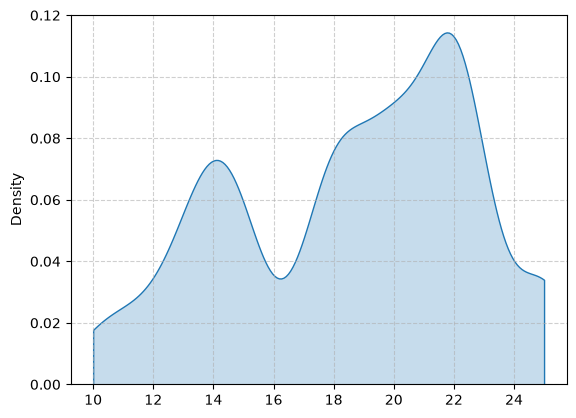

In [146]:
sns.kdeplot((df.iloc[:, 3:] == CORRECT_ANSWERS.values).sum(axis=1), fill=True, clip=[0,25], cut=0, bw_adjust=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Identify Questions with most incorrect responses

In [145]:
num_correct_responses = (df.iloc[:, 3:] == CORRECT_ANSWERS.values).sum(axis=0).values
num_correct_responses = pd.Series(data=num_correct_responses, index=questions).sort_values()
(df.index.size - num_correct_responses).head(5)

Q6     20
Q17    15
Q8     15
Q21    14
Q11    14
dtype: int64